In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\prana\Downloads\archive\health care diabetes.csv")
df.iloc[:, [0, 1, -1]]



,Pregnancies,Glucose,Outcome
0,6,148,1
1,1,85,0
2,8,183,1
3,1,89,0
4,0,137,1
...,...,...,...
763,10,101,0
764,2,122,0
765,5,121,0
766,1,126,1


<AxesSubplot:xlabel='Glucose', ylabel='Density'>

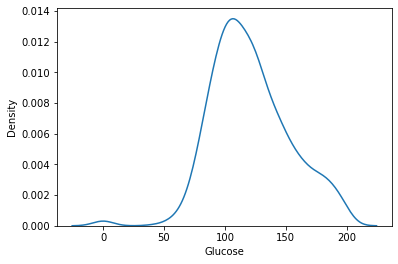

In [18]:
sns.kdeplot(df['Glucose'])

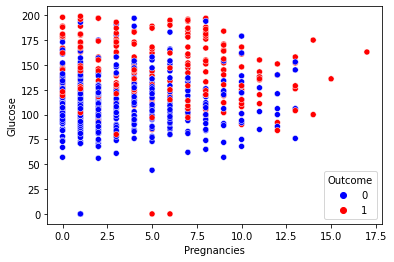

In [20]:
color_dict = {
    0: 'blue',
    1: 'red'
}

sns.scatterplot(
    data=df,
    x='Pregnancies',
    y='Glucose',
    hue='Outcome',
    palette=color_dict
)

plt.show()

# data → Which DataFrame?
# x → Which column on the X-axis?
# y → Which column on the Y-axis?
# hue → Which column decides the colors?
# palette → Which colors should those values get?
# plt.show() → Display the plot.

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    df.drop('Outcome',axis=1),
    df['Outcome'],
    test_size=0.3,
    random_state=0
)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", Y_train.shape)
print("y_test shape :", Y_test.shape)

X_train shape: (537, 8)
X_test shape : (231, 8)
y_train shape: (537,)
y_test shape : (231,)


In [22]:
from sklearn.preprocessing import MinMaxScaler  #xi'=xi=xmin/xmax-xmin
scaler=MinMaxScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [23]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [24]:
np.round(X_train.describe(),1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.0,537.0,537.0,537.0,537.0,537.0,537.0,537.0
mean,3.9,121.5,69.7,21.0,84.9,32.3,0.5,33.7
std,3.4,32.2,19.5,16.0,118.6,8.0,0.3,12.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0
25%,1.0,99.0,64.0,0.0,0.0,27.5,0.2,24.0
50%,3.0,118.0,72.0,24.0,45.0,32.4,0.4,29.0
75%,6.0,142.0,80.0,33.0,135.0,36.8,0.6,41.0
max,17.0,198.0,122.0,99.0,846.0,67.1,2.4,81.0


In [25]:
np.round(X_train_scaled.describe(),1) 

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.0,537.0,537.0,537.0,537.0,537.0,537.0,537.0
mean,0.2,0.6,0.6,0.2,0.1,0.5,0.2,0.2
std,0.2,0.2,0.2,0.2,0.1,0.1,0.1,0.2
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.1,0.5,0.5,0.0,0.0,0.4,0.1,0.1
50%,0.2,0.6,0.6,0.2,0.1,0.5,0.1,0.1
75%,0.4,0.7,0.7,0.3,0.2,0.5,0.2,0.3
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


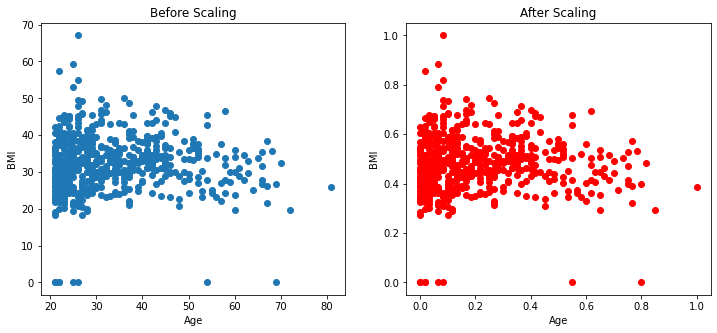

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.scatter(X_train['Age'], X_train['BMI'])
ax1.set_title("Before Scaling")
ax1.set_xlabel("Age")
ax1.set_ylabel("BMI")

# After Scaling
ax2.scatter(X_train_scaled['Age'], X_train_scaled['BMI'], color='red')
ax2.set_title("After Scaling")
ax2.set_xlabel("Age")
ax2.set_ylabel("BMI")

plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

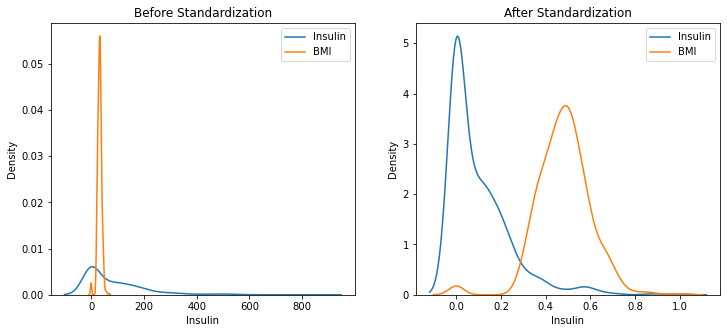

In [27]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
sns.kdeplot(X_train['Insulin'], ax=ax1, label='Insulin')
sns.kdeplot(X_train['BMI'], ax=ax1, label='BMI')
ax1.set_title("Before Standardization")
ax1.legend()

# After Scaling
sns.kdeplot(X_train_scaled['Insulin'], ax=ax2, label='Insulin')
sns.kdeplot(X_train_scaled['BMI'], ax=ax2, label='BMI')
ax2.set_title("After Standardization")
ax2.legend()

plt.show

In [ ]:
# # Min-Max Scaling → Range 0 to 1, sensitive to outliers.
# # Mean Normalization → Centers data around 0.
# # MaxAbs Scaling → Range -1 to 1, keeps 0 unchanged, good for sparse matrices.
# # Robust Scaling → Uses Median & IQR, not affected by outliers.
# # Standardization (Z-score) → Mean = 0, Std = 1, widely used in machine learning.

# # Remember
# # No outliers → Min-Max Scaling
# # Many outliers → Robust Scaling
# # Sparse data → MaxAbs Scaling
# # # Algorithms needing zero-centered data → Standardization or Mean Normalization


# 1. Min-Max Scaling
# Formula:
# x' = (x - xmin) / (xmax - xmin)
# Use:
# Scales data to the range [0, 1]. Best when there are no significant outliers.
# --------------------------------------------------
# 2. Mean Normalization
# Formula:
# x' = (x - mean) / (xmax - xmin)
# Use:
# Centers data around 0 while keeping values within the data range.
# --------------------------------------------------
# 3. MaxAbs Scaling
# Formula:
# x' = x / max(|x|)
# Use:
# Scales data to the range [-1, 1]. Preserves zero and is suitable for sparse data.
# --------------------------------------------------
# 4. Robust Scaling (Robust Normalization)
# Formula:
# x' = (x - Median) / (Q3 - Q1)
# where,
# IQR = Q3 - Q1
# Use:
# Uses Median and IQR, making it robust to outliers.
# --------------------------------------------------
# 5. Standardization (Z-Score Normalization)
# Formula:
# x' = (x - μ) / σ
# where,
# μ = Mean
# σ = Standard Deviation
# Use:
# Transforms data so that the mean is 0 and the standard deviation is 1. Commonly used for Logistic Regression, SVM, KNN, PCA, and Neural Networks.